CNN

1: Importación de Librerías y Rutas Básicas

In [1]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, optimizers, callbacks

# Forzar reproducibilidad absoluta para evitar variaciones entre ejecuciones
np.random.seed(42)
tf.random.set_seed(42)

BASE_DIR = './x-rays'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'validation')
TEST_DIR = os.path.join(BASE_DIR, 'test')
LEADERBOARD_DIR = os.path.join(BASE_DIR, 'leaderboard')
SUBMISSION_PATH = os.path.join(BASE_DIR, 'submission_levi.csv')

# MobileNetV2 requiere mides estándar como (160, 160) o (224, 224) para funcionar de forma óptima
IMG_SIZE = (160, 160)
BATCH_SIZE = 32
EPOCHS = 25

2: Generadores con Aumento de Datos Agresivo y Mapeo Explícito

In [2]:
print("--- Cargando Dataset de Entrenamiento ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

class_names = train_ds.class_names
print(f"Clases asignadas unívocamente: {class_names}")

print("\n--- Cargando Dataset de Validación (Barajado Activo) ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,  # Cambiado a True para estabilizar la métrica val_loss por lote
    seed=42
)

# Pipeline de Aumentación de Imágenes en GPU
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal")
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

--- Cargando Dataset de Entrenamiento ---
Found 351 files belonging to 3 classes.
Clases asignadas unívocamente: ['COVID-19', 'HEALTHY', 'PNEUMONIA']

--- Cargando Dataset de Validación (Barajado Activo) ---
Found 90 files belonging to 3 classes.


3: Arquitectura CNN Optimizada Antioverfitting

In [3]:
# Cargar la base preentrenada excluyendo la capa de clasificación superior
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelamos los pesos originales

# Construcción de la red combinada
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    
    # Preprocesamiento específico nativo que requiere MobileNetV2 (escala a [-1, 1])
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    
    base_model,
    
    # Reducción espacial sin añadir parámetros (evita sobreajuste)
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    
    # Capa final de clasificación para las 3 clases médicas
    layers.Dense(3, activation='softmax')
])

# Usamos una tasa de aprendizaje más conservadora para estabilizar la convergencia
model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

4: Entrenamiento Controlado y Gráficas de Rendimiento

Epoch 1/25


C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\.venv_py312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 662ms/step - accuracy: 0.3818 - loss: 1.7038 - val_accuracy: 0.5111 - val_loss: 0.9897 - learning_rate: 5.0000e-04
Epoch 2/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 521ms/step - accuracy: 0.4843 - loss: 1.1303 - val_accuracy: 0.6556 - val_loss: 0.8307 - learning_rate: 5.0000e-04
Epoch 3/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 644ms/step - accuracy: 0.5840 - loss: 0.9901 - val_accuracy: 0.6444 - val_loss: 0.7507 - learning_rate: 5.0000e-04
Epoch 4/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 573ms/step - accuracy: 0.6781 - loss: 0.7848 - val_accuracy: 0.7111 - val_loss: 0.6643 - learning_rate: 5.0000e-04
Epoch 5/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 723ms/step - accuracy: 0.6752 - loss: 0.7229 - val_accuracy: 0.7667 - val_loss: 0.5972 - learning_rate: 5.0000e-04
Epoch 6/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 606ms/step - accuracy: 0.7436 - loss: 0.6206 - val_accuracy: 0.7778 - val_loss: 0.5374 - learning_rate: 5.0000e-04
Epoch 7/25
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 602ms/step - accuracy: 0.7635 - l

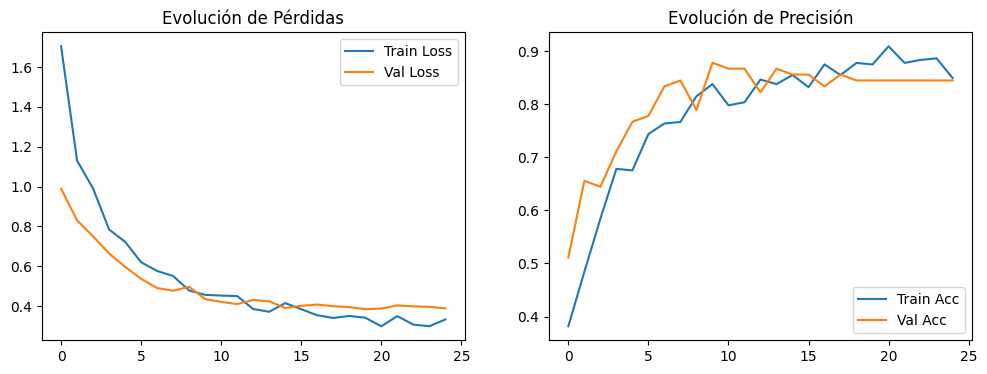

In [4]:
cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list
)

# Monitorización Gráfica
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Evolución de Pérdidas')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Evolución de Precisión')
plt.show()

5: Inferencia del Leaderboard con Mapeo Protegido

In [5]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

def generar_submission_definitiva(modelo, ruta_leaderboard, ruta_csv):
    archivos = [f for f in os.listdir(ruta_leaderboard) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    archivos.sort(key=natural_sort_key)
    
    ids_lista, pred_lista = [], []
    
    print(f"Procesando {len(archivos)} imágenes del Leaderboard...")
    for idx, nombre_archivo in enumerate(archivos):
        id_numerico = int(os.path.splitext(nombre_archivo)[0])
        ruta_completa = os.path.join(ruta_leaderboard, nombre_archivo)
        
        # Carga simétrica. La capa Lambda interna se encarga de adaptar los píxeles
        img = tf.keras.preprocessing.image.load_img(ruta_completa, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        
        preds = modelo.predict(img_array, verbose=0)
        clase_predicha = np.argmax(preds, axis=1)[0]
        
        ids_lista.append(id_numerico)
        pred_lista.append(clase_predicha)
        
        if idx < 3 or idx >= len(archivos) - 3:
            print(f"Imagen: {nombre_archivo} -> ID Asignado: {id_numerico} -> Pred: {clase_predicha}")

    df_sub = pd.DataFrame({'id': ids_lista, 'prediction': pred_lista})
    df_sub.to_csv(ruta_csv, index=False)
    print(f"\n¡Proceso Terminado! Archivo guardado con éxito en: {ruta_csv}")
    return df_sub

df_final = generar_submission_definitiva(model, LEADERBOARD_DIR, SUBMISSION_PATH)

Procesando 116 imágenes del Leaderboard...
Imagen: 1.png -> ID Asignado: 1 -> Pred: 0
Imagen: 2.png -> ID Asignado: 2 -> Pred: 1
Imagen: 3.png -> ID Asignado: 3 -> Pred: 1
Imagen: 114.png -> ID Asignado: 114 -> Pred: 1
Imagen: 115.png -> ID Asignado: 115 -> Pred: 2
Imagen: 116.png -> ID Asignado: 116 -> Pred: 0

¡Proceso Terminado! Archivo guardado con éxito en: ./x-rays\submission_levi.csv
